In [1]:
###https://arxiv.org/pdf/2006.11239###

In [2]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from diffusers import UNet2DModel, DDIMScheduler
import matplotlib.pyplot as plt
from tqdm import tqdm
import logging
import numpy as np
from pathlib import Path
from PIL import Image
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [3]:
class Config:
    # Path configurations
    DATA_DIR = project_root / "data/resized_data/fox"
    WEIGHTS_DIR = project_root / "weights/diffusion"
    HIST_DIR = project_root / "histories/diffusion"
    LOG_DIR = project_root / "logs"
    
    # Image parameters
    IMAGE_SIZE = 112
    CHANNELS = 3
    
    # Training parameters
    BATCH_SIZE = 32
    NUM_EPOCHS = 200
    LR = 1e-4
    T_MAX = NUM_EPOCHS  # For cosine annealing
    ETA_MIN = 1e-6  # Minimum learning rate
    NUM_TIMESTEPS = 1000
    
    # Sampling
    NUM_SAMPLES = 8
    SAMPLING_STEPS = 200
    
    # Device
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Visualization
    PLOT_EVERY = 10
    
    # Random seed
    SEED = 42
    
torch.manual_seed(Config.SEED)
np.random.seed(Config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(Config.SEED)

In [4]:
log_file = Config.LOG_DIR / "diffusion_training.log"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s: %(message)s",
    handlers=[
        logging.FileHandler(log_file, mode="a"),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger()


In [5]:
class DiffusionDataset(Dataset):
    def __init__(self, root_dir):
        self.image_paths = [
            p for p in Path(root_dir).glob("*.*") 
            if p.suffix.lower() in [".jpg", ".png", ".jpeg"]
        ]
        self.transform = transforms.Compose([
            
            transforms.Resize(Config.IMAGE_SIZE),
            transforms.CenterCrop(Config.IMAGE_SIZE),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=5),
            transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), shear=2),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),

            transforms.ToTensor(),
            transforms.RandomErasing(p=0.2,  scale=(0.01, 0.01)),            
            transforms.Normalize([0.5], [0.5], [0.5])  # [-1, 1] range
        ])
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        return self.transform(img), 0  # Return dummy label

In [ ]:
def create_unet():
    return UNet2DModel(
        sample_size=Config.IMAGE_SIZE,
        in_channels=Config.CHANNELS,
        out_channels=Config.CHANNELS,
        layers_per_block=2,
        block_out_channels=(64, 128, 256, 512),
        down_block_types=(
            "DownBlock2D",
            "DownBlock2D",
            "AttnDownBlock2D",
            "DownBlock2D",
        ),
        up_block_types=(
            "UpBlock2D",
            "AttnUpBlock2D",
            "UpBlock2D",
            "UpBlock2D",
        ),
    ).to(Config.device)

In [7]:
def tensor_to_image(tensor):
    """Convert model output tensor to PIL Image"""
    image = tensor.detach().cpu().permute(1, 2, 0).numpy()
    image = (image * 0.5 + 0.5).clip(0, 1)
    return image


In [8]:
def plot_diffusion_steps(images, titles, figsize=(15, 3)):
    """Plot multiple images showing diffusion process"""
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i+1)
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [9]:
def visualize_forward_process(batch, scheduler):
    """Show noise addition at different timesteps using a scaled noise factor"""
    original = batch[0].cpu()
    images = [tensor_to_image(original)]
    titles = ["Original"]
    
    for t in [0.2, 0.4, 0.6, 0.8, 1.0]:
        timestep = torch.tensor(int(t * (Config.NUM_TIMESTEPS - 1)), device=original.device)
        noise = torch.randn_like(original)
        noisy_img = scheduler.add_noise(original, noise, timestep)
        images.append(tensor_to_image(noisy_img))
        titles.append(f"t={timestep.item()}")
    
    plot_diffusion_steps(images, titles)

In [10]:
def generate_samples(model, scheduler, num_images=4):
    """Generate and visualize samples from current model state"""
    model.eval()
    samples = torch.randn((num_images, 3, Config.IMAGE_SIZE, Config.IMAGE_SIZE)).to(Config.device)
    
    intermediate = [tensor_to_image(samples[0])]
    scheduler.set_timesteps(Config.SAMPLING_STEPS)
    
    with torch.no_grad():
        for i, t in enumerate(scheduler.timesteps):
            residual = model(samples, t).sample
            samples = scheduler.step(residual, t, samples).prev_sample
            
            if i % (Config.SAMPLING_STEPS // 5) == 0:
                intermediate.append(tensor_to_image(samples[0]))
    
    plot_diffusion_steps(intermediate, [f"Step {i*(Config.SAMPLING_STEPS//5)}" for i in range(len(intermediate))])
    model.train()

In [11]:
def save_diffusion_model(model, last_epoch_loss, model_name="diffusion"):
    """
    Saves diffusion model weights and training history with merging capability
    
    Args:
        model: Diffusion UNet model
        last_epoch_loss: avg. loss of last epoch
        model_name: Prefix for saved files
    """
    # Ensure directories exist
    Config.WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
    Config.HIST_DIR.mkdir(parents=True, exist_ok=True)

    # Save model weights
    model_path = Config.WEIGHTS_DIR / f"{model_name}_model.pth"
    torch.save(model.state_dict(), model_path)
    
    # Handle training history
    history_path = Config.HIST_DIR / f"{model_name}_history.npz"

    
    # Merge with existing history if available
    if history_path.exists():
        old_history = np.load(history_path)
        old_train = old_history.get("train_losses", np.array([]))
        
        train_losses = np.concatenate([old_train, [last_epoch_loss]])
    else:
        train_losses = np.array([last_epoch_loss])
    
    # Save updated history
    np.savez(history_path,
             train_losses=train_losses,)
    
    logger.info(f"Saved model to: {model_path}")
    logger.info(f"Updated training history at: {history_path}")

def load_diffusion_history(history_path):
    """Load training history for diffusion model"""
    history = np.load(history_path)
    return {
        "train_losses": history["train_losses"]
    }

In [12]:
def train_diffusion(model, dataloader, scheduler):
    optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LR)
    #lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=Config.T_MAX, eta_min=Config.ETA_MIN)
    
    lr_scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=3e-4,  # Higher than initial LR (1e-4)
        total_steps=Config.NUM_EPOCHS * len(dataloader),  # Total batches
        pct_start=0.05,  # 10% of total steps for warmup
        anneal_strategy='cos',  # Smooth decay
        final_div_factor=1e4,  # final_lr = max_lr / 1e4 = 3e-8
    )
    
    scaler = torch.amp.GradScaler("cuda")
    best_loss = float('inf')
    
    train_loss_history = []

    for epoch in range(Config.NUM_EPOCHS):
        model.train()
        epoch_train_loss = 0.0

        # Create a progress bar for batches in the current epoch
        batch_bar = tqdm(dataloader, 
                         desc=f"Epoch {epoch+1}/{Config.NUM_EPOCHS} [Train]",
                         bar_format='{l_bar}{bar:20}{r_bar}{bar:-20b}')

        for batch_idx, batch in enumerate(batch_bar):
            clean_images = batch[0].to(Config.device)
            # Apply noise scaling
            noise = torch.randn_like(clean_images)
            timesteps = torch.randint(
                0, scheduler.config.num_train_timesteps,
                (clean_images.shape[0],),
                device=Config.device
            )
            noisy_images = scheduler.add_noise(clean_images, noise, timesteps)

            optimizer.zero_grad()
            with torch.amp.autocast("cuda"):
                noise_pred = model(noisy_images, timesteps).sample
                loss = F.mse_loss(noise_pred, noise)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_train_loss += loss.item()

            # Update the progress bar with current metrics
            batch_bar.set_postfix({
                'Loss': f"{loss.item():.4f}",
                'LR': f"{optimizer.param_groups[0]['lr']:.1e}"
            })

        avg_train_loss = epoch_train_loss / len(dataloader)
        train_loss_history.append(avg_train_loss)

        logger.info(
            f"Epoch {epoch+1:03d}/{Config.NUM_EPOCHS} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.2e}"
        )

        # Step the dynamic LR scheduler
        lr_scheduler.step()


        save_diffusion_model(model, avg_train_loss, model_name=f"diffusion")
        logger.info(f"Checkpoint saved at epoch {epoch+1}")
        
        if epoch % Config.PLOT_EVERY == 0:
            logger.info(f"Epoch {epoch+1} - Generating samples...")
            generate_samples(model, scheduler)
        

    save_diffusion_model(model, avg_train_loss, model_name="diffusion_final")
    logger.info("Training complete. Final model saved.")


In [13]:
def main(model_path):
    logger.info("Initializing diffusion model training...")
    
    # Create components
    dataset = DiffusionDataset(Config.DATA_DIR)
    dataloader = DataLoader(
        dataset, 
        batch_size=Config.BATCH_SIZE,
        shuffle=True,
        num_workers=20,
        pin_memory=True
    )
    
    model = create_unet()
    model.load_state_dict(torch.load(model_path, map_location=Config.device))
    logger.info(f"Loaded model from {model_path}")
    
    scheduler = DDIMScheduler(  # Replace DDPMScheduler
        num_train_timesteps=Config.NUM_TIMESTEPS,
        beta_schedule="squaredcos_cap_v2",
        clip_sample=True
    )
    
    #logger.info(f"Dataset contains {len(dataloader.dataset)} images")
    #logger.info(f"Model architecture:\n{model}")
    logger.info(f"Training on {Config.device} with {Config.NUM_EPOCHS} epochs")
    
    # Visualize data samples
    sample_batch = next(iter(dataloader))[0][:4]
    visualize_forward_process(sample_batch, scheduler)  # Pass scheduler
    
    # Start training
    train_diffusion(model, dataloader, scheduler)  # Pass scheduler

    
    # Final generation
    logger.info("Training completed. Generating final samples...")
    model.load_state_dict(torch.load(Config.WEIGHTS_DIR / "diffusion_epoch_final.pth"))
    generate_samples(model, scheduler, num_images=Config.NUM_SAMPLES)  # Pass scheduler


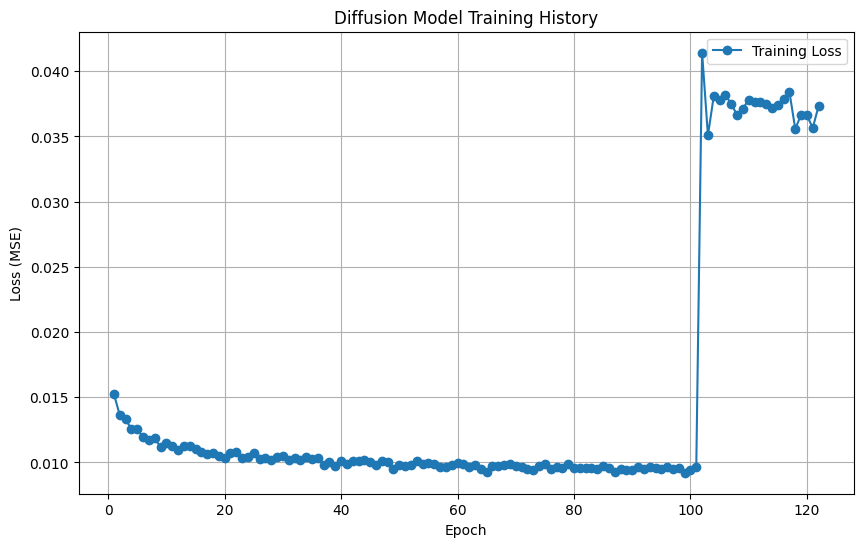

In [14]:
def plot_diffusion_history(history_path):
    """Load and plot the training history for the diffusion model."""
    history = load_diffusion_history(history_path)
    train_losses = history["train_losses"]
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label="Training Loss", marker='o')
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.title("Diffusion Model Training History")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_diffusion_history(Config.HIST_DIR / "diffusion_history.npz")

2025-02-24 00:12:23,810 INFO: Initializing diffusion model training...
2025-02-24 00:12:24,335 INFO: Loaded model from /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/weights/diffusion/diffusion_model.pth
2025-02-24 00:12:24,336 INFO: Training on cuda with 200 epochs


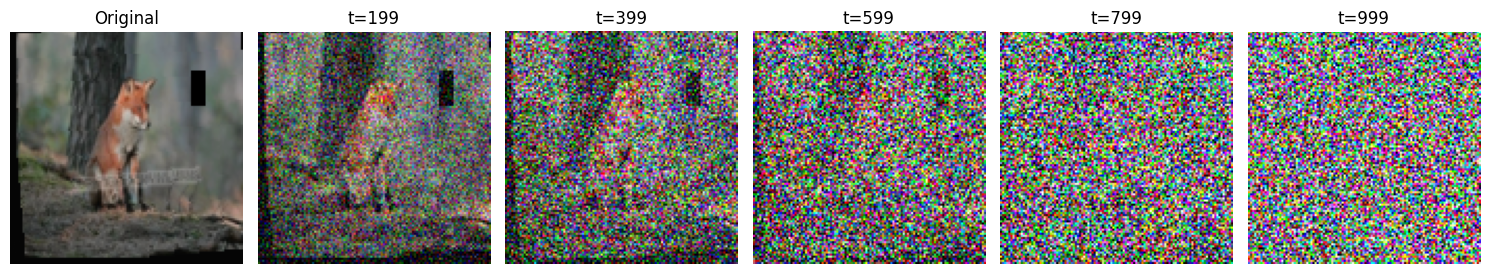

Epoch 1/200 [Train]: 100%|████████████████████| 204/204 [01:26<00:00,  2.36it/s, Loss=0.0301, LR=1.0e-04]
2025-02-24 00:13:51,691 INFO: Epoch 001/200 | Train Loss: 0.0381 | LR: 1.00e-04
2025-02-24 00:13:52,711 INFO: Saved model to: /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/weights/diffusion/diffusion_model.pth
2025-02-24 00:13:52,711 INFO: Updated training history at: /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/histories/diffusion/diffusion_history.npz
2025-02-24 00:13:52,712 INFO: Checkpoint saved at epoch 1
2025-02-24 00:13:52,712 INFO: Epoch 1 - Generating samples...


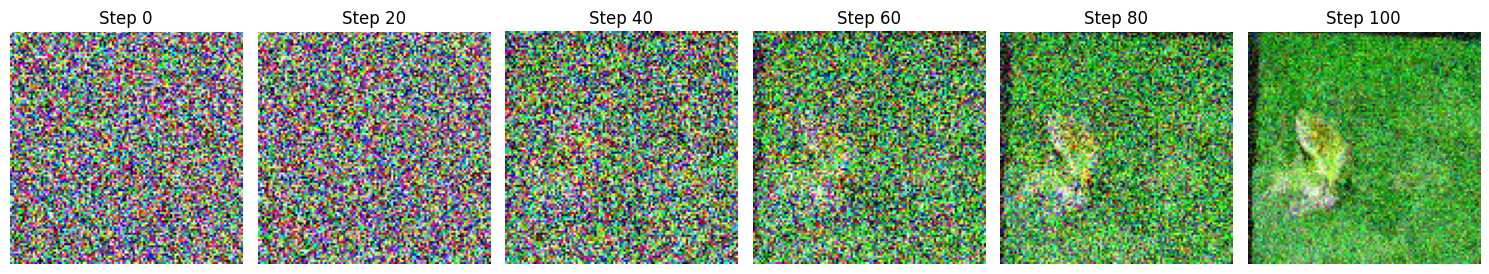

Epoch 2/200 [Train]: 100%|████████████████████| 204/204 [01:27<00:00,  2.33it/s, Loss=0.0356, LR=1.0e-04]
2025-02-24 00:15:23,706 INFO: Epoch 002/200 | Train Loss: 0.0378 | LR: 1.00e-04
2025-02-24 00:15:24,331 INFO: Saved model to: /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/weights/diffusion/diffusion_model.pth
2025-02-24 00:15:24,331 INFO: Updated training history at: /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/histories/diffusion/diffusion_history.npz
2025-02-24 00:15:24,331 INFO: Checkpoint saved at epoch 2
Epoch 3/200 [Train]: 100%|████████████████████| 204/204 [01:26<00:00,  2.37it/s, Loss=0.0273, LR=1.0e-04]
2025-02-24 00:16:50,558 INFO: Epoch 003/200 | Train Loss: 0.0382 | LR: 1.00e-04
2025-02-24 00:16:51,155 INFO: Saved model to: /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/weights/diffusion/diffusion_model.pth
2025-02-24 00:16:51,155 INFO: Updated training history at: /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/histories/diffusion/diffusion_history.

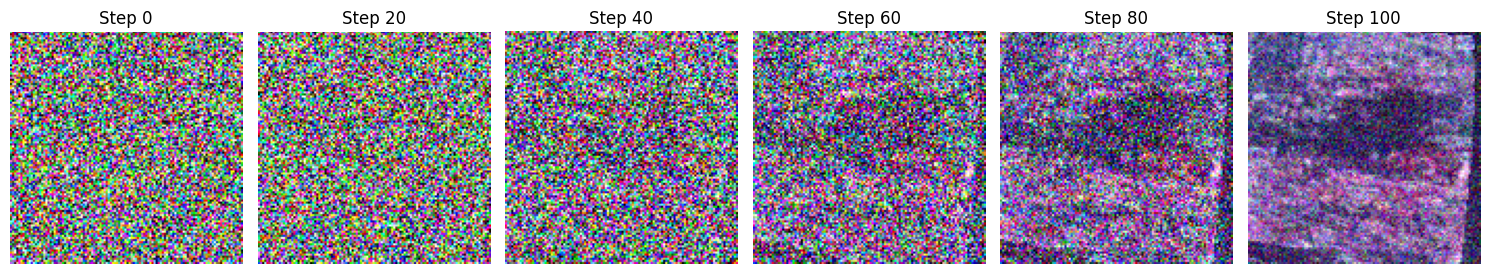

Epoch 12/200 [Train]: 100%|████████████████████| 204/204 [01:22<00:00,  2.48it/s, Loss=0.0075, LR=9.9e-05]
2025-02-24 00:29:50,701 INFO: Epoch 012/200 | Train Loss: 0.0374 | LR: 9.93e-05
2025-02-24 00:29:51,693 INFO: Saved model to: /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/weights/diffusion/diffusion_model.pth
2025-02-24 00:29:51,693 INFO: Updated training history at: /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/histories/diffusion/diffusion_history.npz
2025-02-24 00:29:51,693 INFO: Checkpoint saved at epoch 12
Epoch 13/200 [Train]: 100%|████████████████████| 204/204 [01:25<00:00,  2.40it/s, Loss=0.0266, LR=9.9e-05]
2025-02-24 00:31:16,807 INFO: Epoch 013/200 | Train Loss: 0.0378 | LR: 9.91e-05
2025-02-24 00:31:17,785 INFO: Saved model to: /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/weights/diffusion/diffusion_model.pth
2025-02-24 00:31:17,785 INFO: Updated training history at: /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/histories/diffusion/diffusion_histo

KeyboardInterrupt: 

In [30]:
main(Config.WEIGHTS_DIR / "diffusion_model.pth")

In [15]:
main(Config.WEIGHTS_DIR / "diffusion_model.pth")

2025-02-24 00:47:37,253 INFO: Initializing diffusion model training...


ValueError: Must provide the same number of `block_out_channels` as `down_block_types`. `block_out_channels`: (64, 128, 256, 512, 1024). `down_block_types`: ('DownBlock2D', 'DownBlock2D', 'AttnDownBlock2D', 'DownBlock2D').